In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np

from polyergalio.encoders.pipeline import UniversalPipeline
from polyergalio.encoders import TextProcessor, Tokenizer, SentencePieceTokenizer
from polyergalio.encoders.tokenizer import TokenSequenceBuilder, fit_tokenizer
from polyergalio.generators.data_generators import token_accuracy

from polyergalio.models.constants import ClassificationTask
from polyergalio.models.embedding.embedding import TextEmbedding
from polyergalio.models.embedding.positional import RopeEmbedding
from polyergalio.models.network import Network
from polyergalio.models.layers import (
    DropoutLayer,
    FullyConnectedLayer,
    RMSNormLayer,
    MixtureOfExperts,
    DecisionHead,
    SpectreAttention,
    LatentSum,
    MaskGather
)
from polyergalio.models.layers.decision_layers import (
    decision_correct, decode_decisions, masked_softmax,
)
from polyergalio.models.model_loss import CrossEntropyLoss, DecisionLoss
from polyergalio.models.optimizers import Adam




In [2]:
# THIS IS SUPER KLUDGEY -- clean it up...

In [3]:
# TOKENIZER
TARGET_VOCAB_SIZE = 55_000
SEQUENCE_LENGTH = 500

corpus_path = f"../data/decision_data"
all_json = []

for fn in os.listdir(corpus_path):
    if fn.endswith(".jsonl"):
        with open(f"{corpus_path}/{fn}", "r") as handle:
            for line in handle:
                try:
                    all_json.append(json.loads(line))
                except:
                    continue
    elif fn.endswith(".json"):
        with open(f"{corpus_path}/{fn}", "r") as handle:
            try:
                one_dict = json.loads(line)
                if "options" in one_dict.keys():
                    all_json.append(one_dict)
            except:
                continue



In [4]:
all_json

[{'id': 0,
  'decisiontype': 'choice',
  'instructions': 'この患者にはどのトリアージレベルを割り当てますか？',
  'options': ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急'],
  'state': {'patient_id': 'JA-00001',
   'age': 62,
   'complaint': '手首の骨折の疑い',
   'arrival': '自力来院',
   'heart_rate': 89,
   'systolic_bp': 94,
   'spo2': 94,
   'temperature_c': 38.7,
   'pain_score': 9},
  'answer': 2,
  'option': '3 準緊急',
  'record': {'patient_id': 'JA-00001',
   'age': 62,
   'complaint': '手首の骨折の疑い',
   'arrival': '自力来院',
   'heart_rate': 89,
   'systolic_bp': 94,
   'spo2': 94,
   'temperature_c': 38.7,
   'pain_score': 9}},
 {'id': 1,
  'decisiontype': 'choice',
  'instructions': 'この患者にはどのトリアージレベルを割り当てますか？',
  'options': ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急'],
  'state': {'patient_id': 'JA-00002',
   'age': 23,
   'complaint': '腹痛',
   'arrival': '転院搬送',
   'heart_rate': 79,
   'systolic_bp': 102,
   'spo2': 96,
   'temperature_c': 37.0,
   'pain_score': 0},
  'answer': 2,
  'option': '3 準緊急',
  'record': {'patient_

In [5]:
print(len(all_json))

382304


In [6]:
# flatten out all of our strings for tokenizer fitting --
line_by_line = []
for sample in all_json:
    concat = ""
    try:
        for key, value in sample.items():
            concat += f"{key}: {value}\n"
            line_by_line.append(concat)
        # if "options" in concat:
        #     line_by_line.append(concat)
        # else:
        #     print('skipped')
    except AttributeError:
        print(sample)


In [7]:
print(line_by_line[5])
print(line_by_line[-10])

id: 0
decisiontype: choice
instructions: この患者にはどのトリアージレベルを割り当てますか？
options: ['1 蘇生', '2 緊急', '3 準緊急', '4 低緊急', '5 非緊急']
state: {'patient_id': 'JA-00001', 'age': 62, 'complaint': '手首の骨折の疑い', 'arrival': '自力来院', 'heart_rate': 89, 'systolic_bp': 94, 'spo2': 94, 'temperature_c': 38.7, 'pain_score': 9}
answer: 2

id: 499
decisiontype: score
instructions: Valora esta reseña de restaurante: 0 = muy mala, 2 = normal, 4 = excelente.
options: ['0', '1', '2', '3', '4']
state: {'review_id': 'ES-00500', 'restaurant': 'Mesón Los Olivos', 'price_level': '€', 'review': 'Volveremos seguro, el chuletón es imprescindible. Hasta el postre fue perfecto.'}
answer: 4
option: 4



In [9]:
# model_path = fit_tokenizer(
#     corpus=line_by_line,
#     model_prefix=f"decision_tokenizer",
#     vocab_size=TARGET_VOCAB_SIZE,
#     hard_vocab_limit=False,
# )
#
tokenizer = SentencePieceTokenizer("decision_tokenizer.model")

In [10]:
# tokenizer
feature_encoder = UniversalPipeline(name="feature_encoder")

In [12]:
# Starting -----

from polyergalio.encoders.text_encoders import DistortionTask
# tasks = (DistortionTask.CLOZE,
#          DistortionTask.REPLACED_TOKEN,
#          DistortionTask.TOKEN_DELETION,
#          )
# text_processor = TextProcessor(tokenizer,

feature_encoder = UniversalPipeline(name="feature_encoder")
text_processor = TextProcessor(tokenizer,
                               max_length=SEQUENCE_LENGTH,
                               replace_prob=0.12,
                               max_span_length=SEQUENCE_LENGTH,
                               # tasks=tasks,
                               pool_size=50_000,
                               )

feature_encoder.connect(text_processor, name="tokenizer")
feature_encoder["tokenizer"].fit(line_by_line)
feature_encoder.serialize("spectre_decision_feature.pipeline")
# feature_encoder = UniversalPipeline(name="feature_encoder")

# text_processor.fit(line_by_line)

{'type': 'UniversalPipeline',
 'version': '0.1.6',
 'config': {'name': 'feature_encoder'},
 'state': {'nodes': {'tokenizer': {'sources': ['text'],
    'component': {'type': 'TextProcessor',
     'version': '0.1.6',
     'config': {'target': 'text',
      'max_length': 500,
      'tasks': [<DistortionTask.CLOZE: 'cloze'>,
       <DistortionTask.NEXT_SENTENCE: 'next_sentence'>,
       <DistortionTask.SPAN_BOUNDARY: 'span_boundary'>,
       <DistortionTask.REPLACED_TOKEN: 'replaced_token'>,
       <DistortionTask.TOKEN_DELETION: 'token_deletion'>,
       <DistortionTask.TEXT_INFILLING: 'text_infilling'>],
      'mask_prob': 0.15,
      'replace_prob': 0.12,
      'span_geometric_p': 0.2,
      'max_span_length': 500,
      'negative_sentence_prob': 0.5,
      'delete_prob': 0.15,
      'infill_prob': 0.3,
      'infill_poisson_lambda': 3.0,
      'pool_size': 10000,
      'random_seed': None},
     'state': {'fitted': True,
      'obs_min_max': None,
      'sentence_pool': ['One list of t

In [13]:
# feature_encoder.serialize("spectre_decision_feature.pipeline")
print("feature serialized")

feature serialized


In [ ]:
# ---------------------------------
# LOADING TEXT PIPELINE --
feature_encoder = UniversalPipeline(name="feature_encoder")
feature_encoder = feature_encoder.deserialize("spectre_decision_feature.pipeline")

print(feature_encoder["tokenizer"])
feature_encoder["tokenizer"].max_length = SEQUENCE_LENGTH
feature_encoder["tokenizer"].tokenizer.max_length = SEQUENCE_LENGTH
feature_encoder["tokenizer"].tokenizer.sp.max_sentence_length = SEQUENCE_LENGTH

# double-checking ---
feature_encoder["tokenizer"].encode("this")
feature_encoder["tokenizer"].sentence_pool

In [18]:
HIDDEN_DIM = 800
FFN_HIDDEN = 750
NUM_HEADS = 10
DROPOUT_PROB = 0.10
PADDING_TOK = feature_encoder["tokenizer"].tokenizer.special_tokens.PAD

net = Network(name="spectre_transformer", input_shape=(SEQUENCE_LENGTH,))
embedding = net.connect(
    TextEmbedding(TARGET_VOCAB_SIZE, HIDDEN_DIM, padding_idx=PADDING_TOK), net.input, name="embedding"
)
positional = net.connect(RopeEmbedding(SEQUENCE_LENGTH, HIDDEN_DIM), embedding, name="positional_emb")

# ------ SpectreTF block
at = net.connect(RMSNormLayer(HIDDEN_DIM), positional, name="prenorm_0")
at = net.connect(SpectreAttention(SEQUENCE_LENGTH,
                                  HIDDEN_DIM,
                                  num_heads=NUM_HEADS,
                                  band_radius=32,
                                  memory_tokens=32,
                                  use_wrm=True), at, name="attention_0")
at = net.connect(FullyConnectedLayer(HIDDEN_DIM, FFN_HIDDEN, "swish"), at, name="ffna_0")
at = net.connect(FullyConnectedLayer(FFN_HIDDEN, HIDDEN_DIM, "swish"), at, name="ffnb_0")
at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name="postnorm_0")
at = net.connect(DropoutLayer(DROPOUT_PROB), at, name="dropout_0")
at = net.connect(LatentSum(), at, positional, name="residual_0")

downsample = [20, 20, 10, 10, 10, 5, 5, 2, 2, 0, 0, 0, 0, 0, 0]
for block_idx in range(1, 12):
    use_wrm = True
    # ------ SpectreTF blocks
    at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name=f"prenorm_{block_idx}")
    at = net.connect(SpectreAttention(SEQUENCE_LENGTH,
                                      HIDDEN_DIM,
                                      num_heads=NUM_HEADS,
                                      band_radius=downsample[block_idx - 1],
                                      memory_tokens=50,
                                      use_wrm=use_wrm
                                      ), at, name=f"attention_{block_idx}")
    if (block_idx % 2) == 0:
        at = net.connect(MixtureOfExperts(input_dim=HIDDEN_DIM,
                                          upscale_dim=int(1.25 * HIDDEN_DIM),
                                          hidden_dim=FFN_HIDDEN,
                                          num_shared_experts=1,
                                          num_routed_experts=24,
                                          top_k=4,
                                          num_groups=8,
                                          top_groups=4,
                                          routed_scaling=1.2), at, name=f"ffnmoe_{block_idx}")
    else:
        at = net.connect(FullyConnectedLayer(HIDDEN_DIM, FFN_HIDDEN, "swish"), at, name=f"ffna_{block_idx}")

    at = net.connect(FullyConnectedLayer(FFN_HIDDEN, HIDDEN_DIM, "swish"), at, name=f"ffnb_{block_idx}")
    at = net.connect(RMSNormLayer(HIDDEN_DIM), at, name=f"postnorm_{block_idx}")
    at = net.connect(DropoutLayer(DROPOUT_PROB), at, name=f"dropout_{block_idx}")
    at = net.connect(LatentSum(), at, positional, name=f"residual_{block_idx}")

gathered = net.connect(MaskGather(), at, name="mask_gather")
net.output = net.connect(
    FullyConnectedLayer(HIDDEN_DIM, TARGET_VOCAB_SIZE, "linear", is_output=True), gathered, name="mlm_head"
)

In [19]:
print(net.summary())

spectre_transformer: 88 nodes, 181453872 parameters
  node            sources                    shape
  embedding       input                      (500, 800)
  positional_emb  embedding                  (800,)
  prenorm_0       positional_emb             (800,)
  attention_0     prenorm_0                  (800,)
  ffna_0          attention_0                (750,)
  ffnb_0          ffna_0                     (800,)
  postnorm_0      ffnb_0                     (800,)
  dropout_0       postnorm_0                 (800,)
  residual_0      dropout_0,positional_emb   (None,)
  prenorm_1       residual_0                 (800,)
  attention_1     prenorm_1                  (800,)
  ffna_1          attention_1                (750,)
  ffnb_1          ffna_1                     (800,)
  postnorm_1      ffnb_1                     (800,)
  dropout_1       postnorm_1                 (800,)
  residual_1      dropout_1,positional_emb   (None,)
  prenorm_2       residual_1                 (800,)
  atten

edges:
  input      -> embedding
  embedding  -> positional_emb
  positional_emb -> prenorm_0
  prenorm_0  -> attention_0
  attention_0 -> ffna_0
  ffna_0     -> ffnb_0
  ffnb_0     -> postnorm_0
  postnorm_0 -> dropout_0
  dropout_0  -> residual_0
  positional_emb -> residual_0
  residual_0 -> prenorm_1
  prenorm_1  -> attention_1
  attention_1 -> ffna_1
  ffna_1     -> ffnb_1
  ffnb_1     -> postnorm_1
  postnorm_1 -> dropout_1
  dropout_1  -> residual_1
  positional_emb -> residual_1
  residual_1 -> prenorm_2
  prenorm_2  -> attention_2
  attention_2 -> ffnmoe_2
  ffnmoe_2   -> ffnb_2
  ffnb_2     -> postnorm_2
  postnorm_2 -> dropout_2
  dropout_2  -> residual_2
  positional_emb -> residual_2
  residual_2 -> prenorm_3
  prenorm_3  -> attention_3
  attention_3 -> ffna_3
  ffna_3     -> ffnb_3
  ffnb_3     -> postnorm_3
  postnorm_3 -> dropout_3
  dropout_3  -> residual_3
  positional_emb -> residual_3
  residual_3 -> prenorm_4
  prenorm_4  -> attention_4
  attention_4 -> ffnmoe_4
  

<Axes: title={'center': 'spectre_transformer'}>

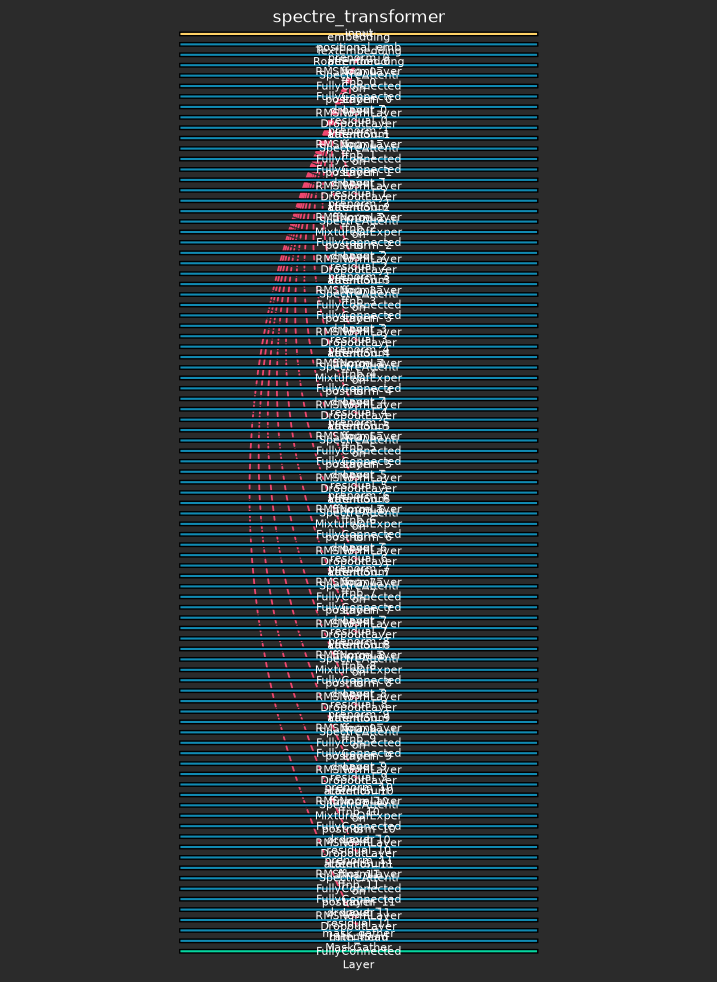

In [20]:
from polyergalio.visuals.nnet_visuals import plot_network

print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
_temp = feature_encoder["tokenizer"].encode("this is a go")
print(net.summary(_temp["text"]))
plot_network(net)

In [21]:
print(net.timing_summary(top=20))

spectre_transformer: per-node timing
  node           fwd avg (ms)  fwd total (s)  bwd avg (ms)  bwd total (s)
  mlm_head           6202.744         6.2027         0.000         0.0000
  ffnmoe_8           1264.497         1.2645         0.000         0.0000
  ffnmoe_10          1162.994         1.1630         0.000         0.0000
  ffnmoe_2            654.807         0.6548         0.000         0.0000
  ffnmoe_6            633.586         0.6336         0.000         0.0000
  ffnmoe_4            628.064         0.6281         0.000         0.0000
  attention_10        336.742         0.3367         0.000         0.0000
  attention_0         251.979         0.2520         0.000         0.0000
  attention_7         236.519         0.2365         0.000         0.0000
  attention_2         235.375         0.2354         0.000         0.0000
  attention_4         235.346         0.2353         0.000         0.0000
  attention_8         232.747         0.2327         0.000         0.0000
 

In [22]:
def mlm_accuracy(net: Network, processor: TextProcessor, texts: list[str]) -> float:
    """Accuracy at masked positions of a cloze batch, with the network in eval mode."""
    batch = processor.distort_batch(texts, "cloze")
    net.eval()
    logits = net.forward(batch["input_ids"], mask=batch["attention_mask"], target_mask=batch["target_mask"])
    return token_accuracy(np.argmax(logits, axis=-1), batch["labels"][batch["target_mask"]])


print(net)

Network(88 nodes, 181453872 parameters)


In [23]:
# feature_encoder pipeline needs to have visibility into these subprocesses:
data = feature_encoder["tokenizer"].distort_batch(line_by_line[-5:])
data.keys()

dict_keys(['input_ids', 'attention_mask', 'segment_ids', 'target_mask', 'labels', 'task'])

In [24]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(line_by_line), p=[0.05, 0.95])
for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(line_by_line[idx])
    else:
        training.append(line_by_line[idx])

print(len(held_out))
print(len(training))

133447
2545683


In [25]:
len(feature_encoder["tokenizer"].sentence_pool)

10000

In [26]:
# deserialize

net = net.deserialize("spectre_nnet.ergalio")

Automatic pdb calling has been turned ON
training will take 1272841.5 steps
text_infilling
mlm step    0  loss 2.5266
took 2.7889821529388428


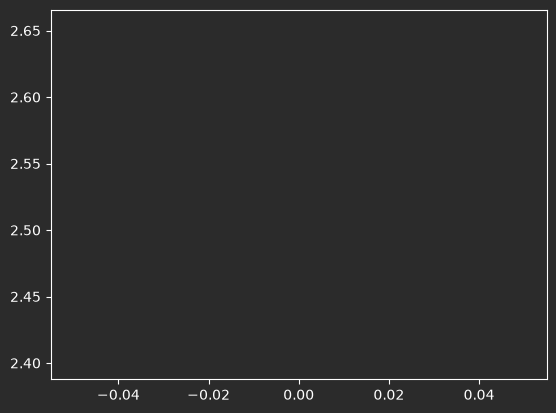

masked-token accuracy after training:  0.069
token_deletion
mlm step  100  loss 0.5002
took 1.593677043914795


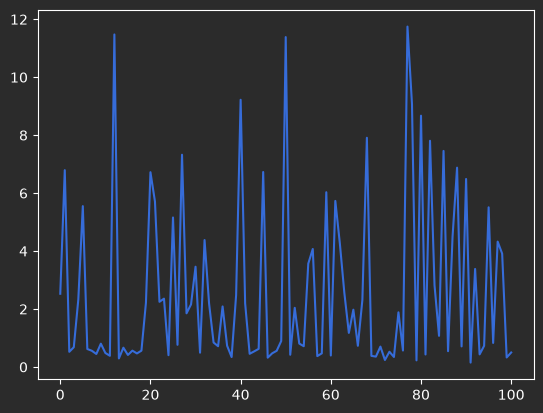

masked-token accuracy after training:  0.073
cloze
mlm step  200  loss 7.1184
took 1.1606221199035645


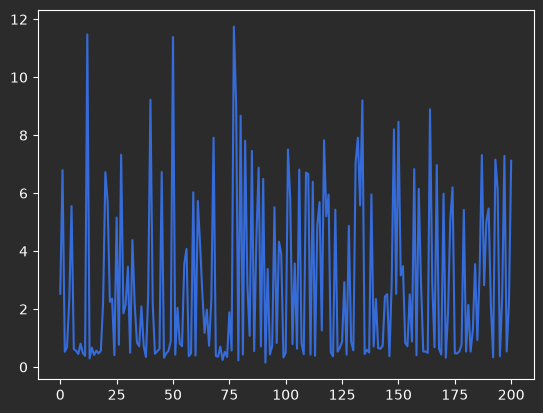

masked-token accuracy after training:  0.571
span_boundary
mlm step  300  loss 5.4345
took 1.0112252235412598


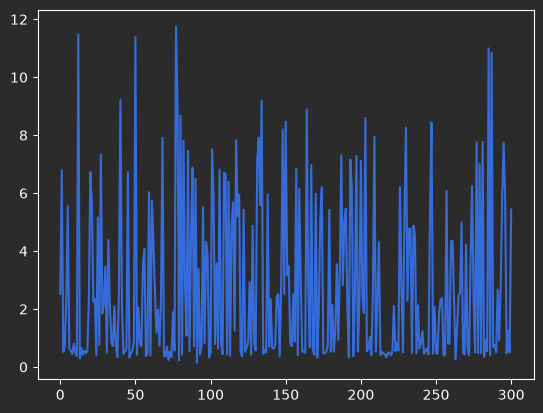

masked-token accuracy after training:  0.250
token_deletion
mlm step  400  loss 0.4689
took 1.286214828491211


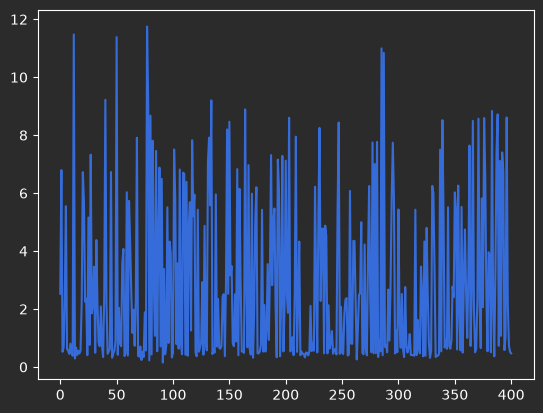

masked-token accuracy after training:  0.000
text_infilling
mlm step  500  loss 2.7292
took 1.254054069519043


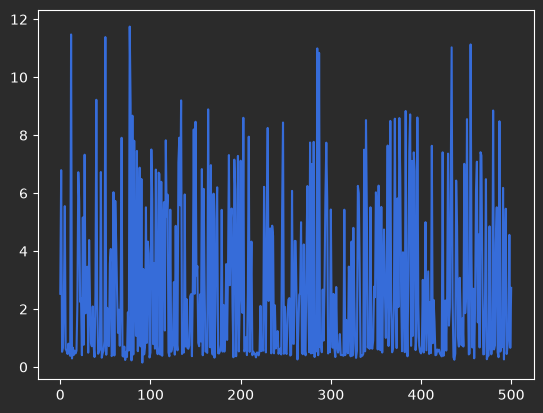

masked-token accuracy after training:  0.069
cloze
mlm step  600  loss 6.5502
took 0.9709439277648926


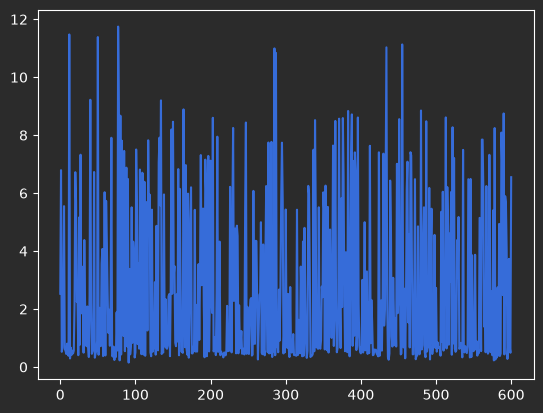

masked-token accuracy after training:  0.000
token_deletion
mlm step  700  loss 0.4291
took 1.1881651878356934


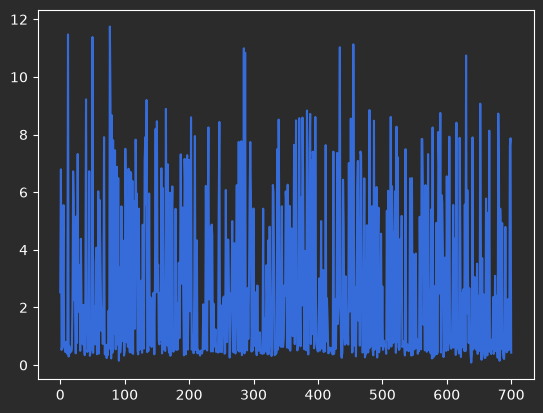

masked-token accuracy after training:  0.273
replaced_token
mlm step  800  loss 0.4038
took 1.0028321743011475


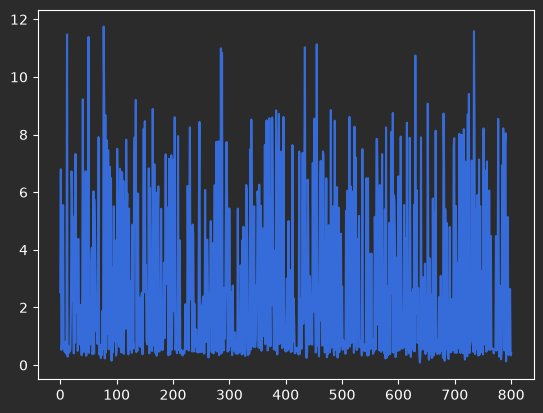

masked-token accuracy after training:  0.500
cloze
mlm step  900  loss 9.4336
took 0.9405992031097412


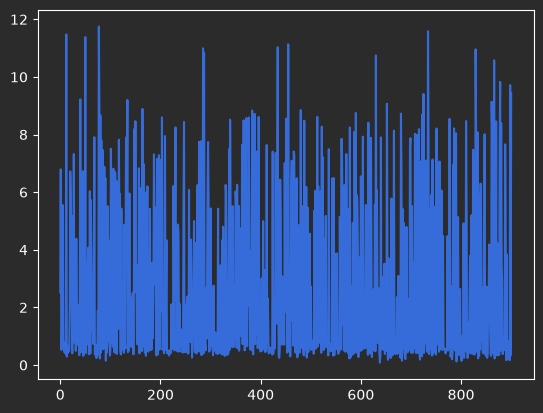

masked-token accuracy after training:  0.071
token_deletion
mlm step 1000  loss 0.6128
took 1.49068021774292


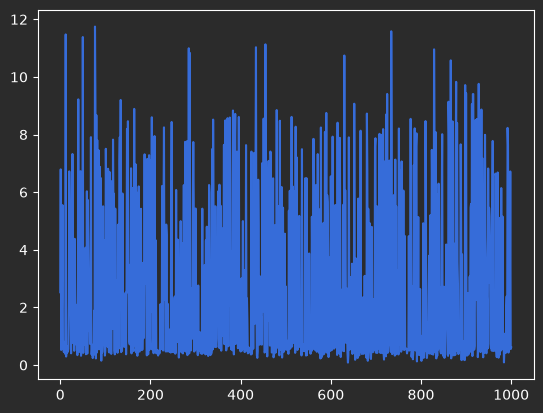

masked-token accuracy after training:  0.429
token_deletion
mlm step 1100  loss 0.4796
took 0.997002124786377


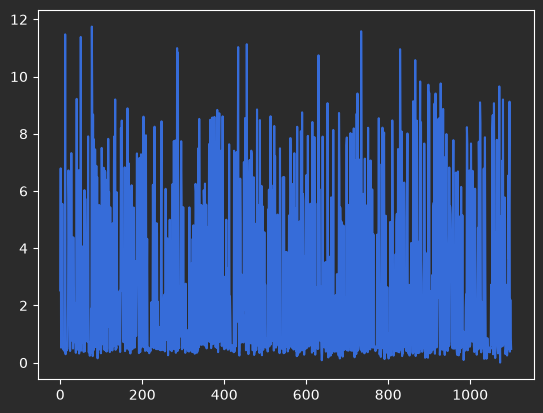

masked-token accuracy after training:  0.200
next_sentence
mlm step 1200  loss 0.4923
took 0.9624819755554199


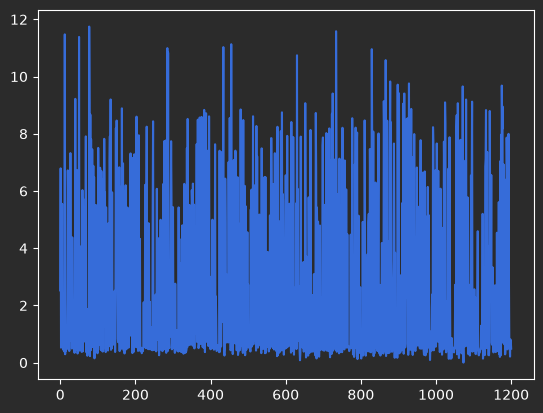

masked-token accuracy after training:  0.090
token_deletion
mlm step 1300  loss 0.7018
took 1.0576667785644531


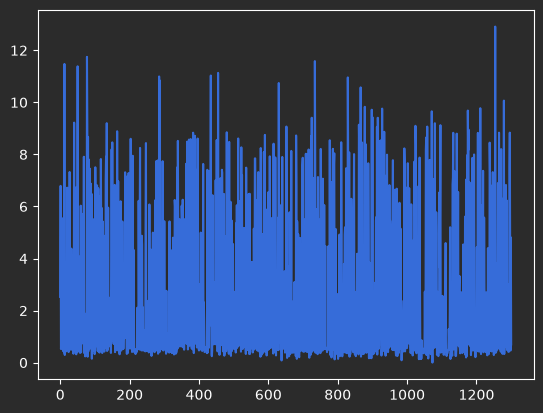

masked-token accuracy after training:  0.154
span_boundary
mlm step 1400  loss 6.8795
took 1.0031769275665283


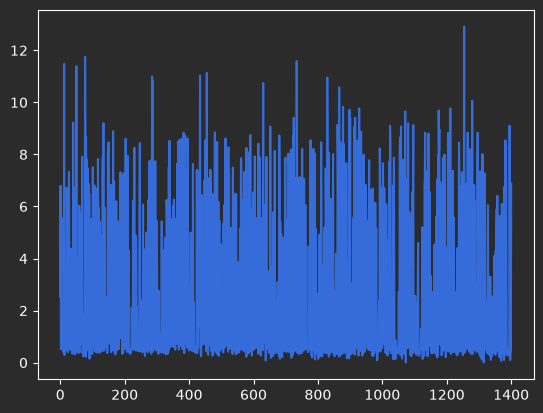

masked-token accuracy after training:  0.429


KeyboardInterrupt: 

> /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/polyergalio/models/activations.py(65)linear()
     63 
     64 
---> 65 @activation
     66 def linear(x_array: NDArray) -> NDArray:
     67     """linear forward - for regression"""



In [28]:
import random
%pdb on
BATCH_SIZE = 2
LR = 4e-4
EPOCHS = 10
LOG_EVERY = 100
_targets = np.eye(TARGET_VOCAB_SIZE)

all_loss = []
loss_fn = CrossEntropyLoss(task=ClassificationTask.MULTINOMIAL)
optimizer = Adam(LR)

for epoch in range(0, EPOCHS):
    np.random.shuffle(training)
    optimizer.learning_rate = LR * (0.92 ** epoch)
    print(f"training will take {len(training) / BATCH_SIZE} steps")

    for step, start_idx in enumerate(range(150, len(training), BATCH_SIZE)):
        net.train()
        _mini_batch = training[start_idx:start_idx + BATCH_SIZE]

        _tok_batch = feature_encoder["tokenizer"].distort_batch(_mini_batch)

        tokens, labels = _tok_batch["input_ids"], _tok_batch["labels"]
        attention_mask, target_mask = _tok_batch["attention_mask"], _tok_batch["target_mask"]
        targets = labels[target_mask]

        st = time.time()
        logits = net.forward(tokens, mask=attention_mask, target_mask=target_mask)

        loss = loss_fn(logits, _targets[targets])
        stt = time.time() - st

        net.backward(loss_fn.backward())
        optimizer.step(net)
        net.zero_gradients()
        all_loss.append(loss.item())

        if step % LOG_EVERY == 0:
            print(_tok_batch["task"])
            print(f"mlm step {step:4d}  loss {loss:.4f}")
            print(f"took {stt}")
            plt.plot(all_loss)
            plt.show()
            print(f"masked-token accuracy after training:  {mlm_accuracy(net,
                                                                         feature_encoder["tokenizer"],
                                                                         random.choices(held_out, k=BATCH_SIZE)
                                                                         ):.3f}")

            net.serialize("spectre_nnet.ergalio")

    net.serialize("spectre_nnet.ergalio")
    print(f"masked-token accuracy after training:  {mlm_accuracy(net,
                                                                 feature_encoder["tokenizer"],
                                                                 random.choices(held_out, k=BATCH_SIZE)
                                                                 ):.3f}")


In [ ]:
print(_tok_batch["task"])
print(f"mlm step {step:4d}  loss {loss:.4f}")
print(f"took {stt}")
plt.plot(all_loss)
plt.show()
print(f"masked-token accuracy after training:  {mlm_accuracy(net,
                                                             feature_encoder["tokenizer"],
                                                             random.choices(held_out, k=BATCH_SIZE)
                                                             ):.3f}")

net.serialize("spectre_nnet.ergalio")

In [ ]:
# deserialize
net = net.deserialize("spectre_nnet.ergalio")

In [ ]:
HIDDEN_DIM = 720
net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
                                      head_hidden=HIDDEN_DIM,
                                      routed_scaling=1.5,
                                      num_groups=16,
                                      top_groups=8),
                         net.node("residual_11"),
                         name="decision_moe_out")

net.disconnect(net.node("decision_moe"))
net.delete(net.node("decision_moe"))

net.purge()
plot_network(net)

In [ ]:
# how to disconnect / reconnect ----------
# pooler = net.connect(PoolingLayer(),
#                      net.node("residual_11"),
#                      name="pooling")
# HIDDEN_DIM=720
#
# net.output = net.connect(DecisionHead(hidden_dim=HIDDEN_DIM,
#                                       head_hidden=HIDDEN_DIM),
#                          net.node("residual_11"),
#                          name="decision_moe")
#
# net.disconnect(net.node("mask_gather"))
# net.delete(net.node("mask_gather"))
# net.disconnect(net.node("mlm_head"))
# net.delete(net.node("mlm_head"))
#
# net.purge()
# plot_network(net)


task_processor = TokenSequenceBuilder(tokenizer)

task_processor.build_decision_batch(samples, max_length=None)

## yields :
token_ids (batch, sequence_length)
mask (batch, sequence_length) — the encoder's attention mask, token_ids != PAD
marker_pos -> marker token positions (the start of a span)
marker_end -> marker_end token positions (the ending of a span)
token_mask (batch, options) — DecisionHead's own kwargs
decisiontypes (batch,) - one Enum per task
answers (batch,), included only when every sample carries an answer

In [ ]:

sample = [
    {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     },
    {"id": 0,
     "decisiontype": "choice",
     "instructions": "What should be done with this inventory item?",
     "options": ["reorder", "discount", "hold", "discontinue"],

     "state": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None},
     "answer": 3,
     "option": "discontinue",
     "record": {"sku": "SKU-4122", "item": "HDMI cable", "stock": 324, "weekly_sales": 1, "days_to_expiry": None}
     }
]

task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)

# task_processor.build_decision_batch
batch = task_processor.build_decision_batch(sample, max_length=512)
# target = (batch["answer"], batch["option"])


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")

st = time.time()
logits = net.forward(batch["token_ids"],
                     mask=batch["mask"],
                     marker_pos=batch["marker_pos"],
                     marker_end=batch["marker_end"],
                     token_mask=batch["token_mask"],
                     decisiontypes=batch["decisiontypes"])
print(f'naive forward took {(time.time() - st) / len(sample)} per sample row')
print(net.timing_summary(top=10))


In [ ]:
batch

In [ ]:
loss = DecisionLoss(ordinal_weight=0.25)(logits,
                                         batch["answers"],
                                         batch["token_mask"],
                                         batch["decisiontypes"])

print(loss)
print(logits)

In [ ]:
print(net)
# 159_260_541

In [ ]:
held_out = []
training = []
samples = np.random.choice([True, False], replace=True, size=len(all_json), p=[0.05, 0.95])

for idx, hold in enumerate(samples):
    if hold == True:
        held_out.append(all_json[idx])
    else:
        training.append(all_json[idx])

print(len(held_out))
print(len(training))

In [ ]:
net = NeuralNetwork()
net = net.deserialize("spectre_nnet_decider.ergalio")

In [ ]:
net.layers

In [ ]:


BATCH_SIZE = 5
LR = 2e-4
ACT_WEIGHT = 0.01
EPOCHS = 10
LOG_EVERY = 50

all_loss, all_act_loss = [], []
loss_fn = DecisionLoss(ordinal_weight=0.25)
task_processor = TokenSequenceBuilder(feature_encoder["tokenizer"].tokenizer)
optimizer = Adam(LR)

# held_out ----
test_accuracy = []

for epoch in range(0, EPOCHS):
    np.random.shuffle(training)
    optimizer.learning_rate = LR * (0.92 ** epoch)
    net.node("decision_moe_out").component.act_weight = ACT_WEIGHT * (1.2 ** epoch)
    print(f"training will take {len(training) / BATCH_SIZE} steps")

    net.eval()
    net.node("decision_moe_out").component.train()

    for step, start_idx in enumerate(range(0, len(training), BATCH_SIZE)):
        net.zero_gradients()
        _mini_batch = training[start_idx:start_idx + BATCH_SIZE]

        _tok_batch = task_processor.build_decision_batch(
            _mini_batch,
            max_length=SEQUENCE_LENGTH)
        # target = (sample["answer"], sample["option"])

        logits = net.forward(_tok_batch["token_ids"],
                             mask=_tok_batch["mask"],
                             marker_pos=_tok_batch["marker_pos"],
                             marker_end=_tok_batch["marker_end"],
                             token_mask=_tok_batch["token_mask"],
                             decisiontypes=_tok_batch["decisiontypes"])

        act = net.node("decision_moe_out").component.score_act(_tok_batch["answers"])

        loss = loss_fn(logits,
                       _tok_batch["answers"],
                       _tok_batch["token_mask"],
                       _tok_batch["decisiontypes"])

        net.backward(loss_fn.backward())
        optimizer.step(net.layers)

        all_loss.append(loss)
        all_act_loss.append(act)

        this_step = []
        timings = []
        if (step + 1) % LOG_EVERY == 0:
            plt.clf()
            for batch in range(0, len(held_out), BATCH_SIZE):
                st = time.time()
                _tok_batch = task_processor.build_decision_batch(
                    held_out[batch:batch + BATCH_SIZE],
                    # random.choices(held_out, k=BATCH_SIZE),
                    max_length=SEQUENCE_LENGTH)

                net.zero_gradients()
                logits = net.forward(_tok_batch["token_ids"],
                                     mask=_tok_batch["mask"],
                                     marker_pos=_tok_batch["marker_pos"],
                                     marker_end=_tok_batch["marker_end"],
                                     token_mask=_tok_batch["token_mask"],
                                     decisiontypes=_tok_batch["decisiontypes"])

                act = net.node("decision_moe_out").component.score_act(_tok_batch["answers"])
                timings.append(st - time.time())
                loss = loss_fn(logits,
                               _tok_batch["answers"],
                               _tok_batch["token_mask"],
                               _tok_batch["decisiontypes"])

                classes = np.argmax(logits, axis=-1)
                acc = np.sum(classes == _tok_batch["answers"]) / len(classes)
                this_step.append(acc)

            print("decision_types: ", _tok_batch["decisiontypes"])
            print("answer_targets: ", _tok_batch["answers"])
            print("predicted:      ", np.argmax(logits, axis=-1))
            print("esc? : ", net.node("decision_moe_out").component.escalate(0.5))
            print(f"Losses for step {step:4d} \n\t- Decision loss {loss:.4f} \n\t- Confidence loss {act:.4f} ")

            avg = np.mean(timings)
            print(f"mean timings of test dataset per batch of {BATCH_SIZE}: {avg}, \n per sample {avg / BATCH_SIZE}")

            test_accuracy.append(np.mean(this_step))
            print("accuracy:", test_accuracy[-5:])

            plt.figure()
            plt.subplot(3, 1, 1)
            plt.title("Decision Loss")
            plt.plot(all_loss)
            plt.subplot(3, 1, 2)
            plt.title("Confidence/action loss")
            plt.plot(all_act_loss, color="red")
            plt.subplot(3, 1, 3)
            plt.title("test set accuracy")
            plt.plot(test_accuracy, color="green")
            plt.show()

    net.serialize("spectre_nnet_decider.ergalio")


In [ ]:
net.serialize("spectre_nnet_decider.ergalio")